Use any dataset such as: Titanic, housing, etc and perform all the feature engineering techniques:

Check list:
1. handle missing value
2. handle categorical value
3. Scale the features
4. remove outliers
5. feature selection
6. PCA

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load dataset

# Load dataset
def load_titanic_data(TITANIC_PATH):
  return pd.read_csv(TITANIC_PATH)


df = load_titanic_data("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


1. Handle Missing Value

In [3]:
print("Count missing values in each column of a dataset")

missing_counts = df.isnull().sum()
print(missing_counts)

Count missing values in each column of a dataset
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Remove missing values

In [4]:
# Drop rows with any missing values
df_dropped_rows = df.dropna()
print("\nDataFrame after dropping rows with missing values:")
print(df_dropped_rows)


DataFrame after dropping rows with missing values:
     PassengerId  Survived  Pclass  \
1              2         1       1   
3              4         1       1   
6              7         0       1   
10            11         1       3   
11            12         1       1   
..           ...       ...     ...   
871          872         1       1   
872          873         0       1   
879          880         1       1   
887          888         1       1   
889          890         1       1   

                                                  Name     Sex   Age  SibSp  \
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
6                              McCarthy, Mr. Timothy J    male  54.0      0   
10                     Sandstrom, Miss. Marguerite Rut  female   4.0      1   
11                            Bonnell, Miss. Elizabeth  female  58.0      0   
..               

Impute missing values with the median

In [5]:
df_median = df
df_median['Age'].fillna(df_median['Age'].median(), inplace=True)

print("\nDataFrame after imputing numerical columns with median:")
print(df_median)


DataFrame after imputing numerical columns with median:
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..          

/var/folders/x3/0srfcn6n79n23q_97w7dqypm0000gn/T/ipykernel_5038/1687015349.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_median['Age'].fillna(df_median['Age'].median(), inplace=True)



Impute missing values with the mode

In [6]:
df_mode = df
df_mode['Cabin'].fillna(df_mode['Cabin'].mode()[0], inplace=True)


print("\nDataFrame after imputing categorical columns with mode:")
print(df_mode)


DataFrame after imputing categorical columns with mode:
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..          

/var/folders/x3/0srfcn6n79n23q_97w7dqypm0000gn/T/ipykernel_5038/850701215.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mode['Cabin'].fillna(df_mode['Cabin'].mode()[0], inplace=True)



2.Handle Categorical Value

In [7]:
df = df.drop(columns=['Embarked']) # Enbarked is dropped

In [8]:
print("After handling all missing values")
print(df.isnull().sum())

After handling all missing values
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
dtype: int64


3.Feature Scaling
Standardization (Z-score Normalization)

In [11]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler

# Initialize scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()


# Apply scalers
df['Age'] = standard_scaler.fit_transform(df[['Age']])


# Display results
print("\nStandard Scaled Age:\n", df['Age'])


Standard Scaled Age:
 0     -0.565736
1      0.663861
2     -0.258337
3      0.433312
4      0.433312
         ...   
886   -0.181487
887   -0.796286
888   -0.104637
889   -0.258337
890    0.202762
Name: Age, Length: 891, dtype: float64


MinMax Scaling

In [12]:
minmax_scaler = MinMaxScaler()

df['Fare'] = minmax_scaler.fit_transform(df[['Fare']])

# Display results
print("\nMinmax Scaled Fare:\n", df['Fare'])


Minmax Scaled Fare:
 0      0.014151
1      0.139136
2      0.015469
3      0.103644
4      0.015713
         ...   
886    0.025374
887    0.058556
888    0.045771
889    0.058556
890    0.015127
Name: Fare, Length: 891, dtype: float64


Robust Scaling


In [13]:

robust_scaler = RobustScaler()

df['Age'] = robust_scaler.fit_transform(df[['Age']])

# Display results
print("\nRobust Scaled Age:\n", df['Age'])


Robust Scaled Age:
 0     -0.461538
1      0.769231
2     -0.153846
3      0.538462
4      0.538462
         ...   
886   -0.076923
887   -0.692308
888    0.000000
889   -0.153846
890    0.307692
Name: Age, Length: 891, dtype: float64


mAXabs Scaling

In [14]:
maxabs_scaler = MaxAbsScaler()

df['Fare'] = maxabs_scaler.fit_transform(df[['Fare']])

#Display results
print("\n MaxAbs scaled Fare",df['Fare'])


 MaxAbs scaled Fare 0      0.014151
1      0.139136
2      0.015469
3      0.103644
4      0.015713
         ...   
886    0.025374
887    0.058556
888    0.045771
889    0.058556
890    0.015127
Name: Fare, Length: 891, dtype: float64



4.REMOVING OUTLIERS

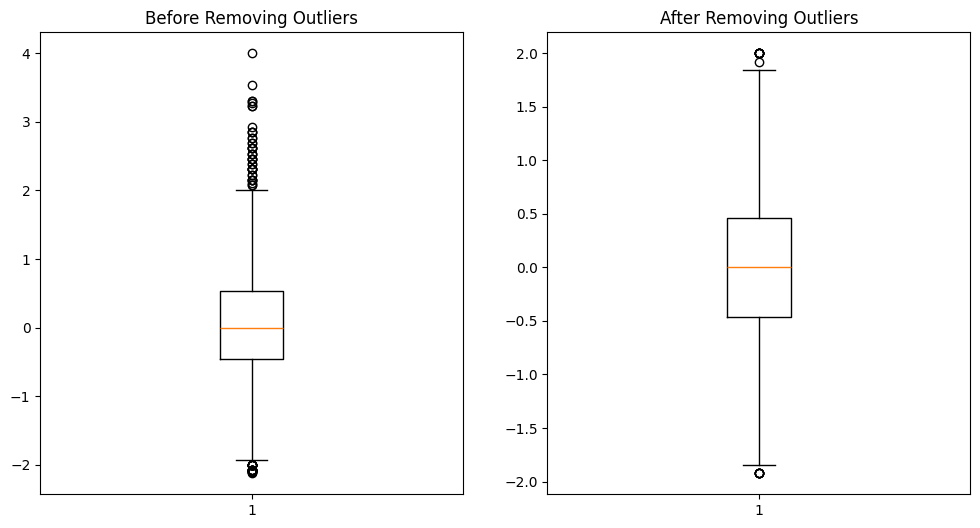

Data after removing outliers:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex       Age  SibSp  \
0                            Braund, Mr. Owen Harris    male -0.461538      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  0.769231      1   
2                             Heikkinen, Miss. Laina  female -0.153846      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  0.538462      1   
4                           Allen, Mr. William Henry    male  0.538462      0   

   Parch            Ticket      Fare    Cabin  
0      0         A/5 21171  0.014151  B96 B98  
1      0          PC 17599  0.139136      C85  
2      0  STON/O2. 3101282  0.015469  B96 B98  
3      0            113803  0.103644     C123  
4      0            373450

In [15]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Calculate Q1, Q3, and IQR
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_filtered = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]

# Plot before and after removing outliers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.boxplot(df['Age'])
ax1.set_title("Before Removing Outliers")

ax2.boxplot(df_filtered['Age'])
ax2.set_title("After Removing Outliers")

plt.show()

print("Data after removing outliers:")
print(df_filtered.head())


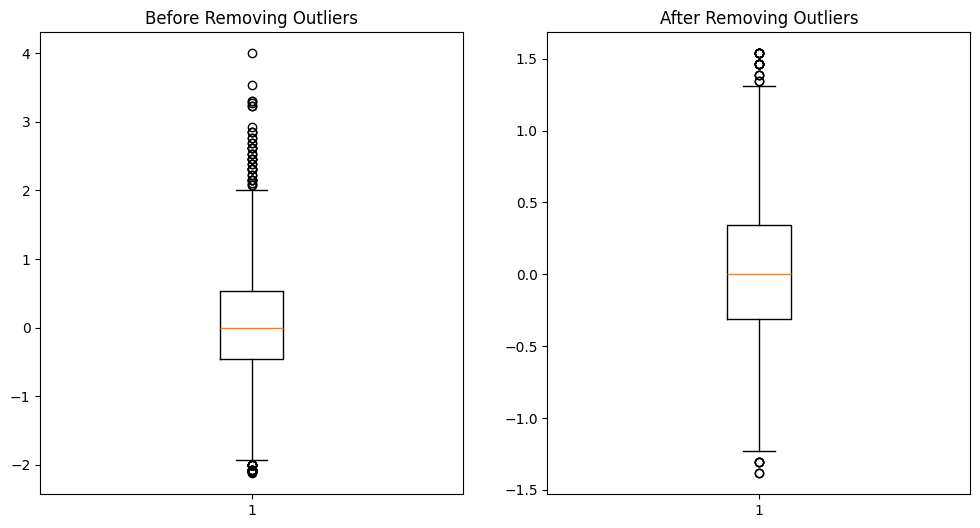

Data after removing outliers (Z-score method):
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex       Age  SibSp  \
0                            Braund, Mr. Owen Harris    male -0.461538      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  0.769231      1   
2                             Heikkinen, Miss. Laina  female -0.153846      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  0.538462      1   
4                           Allen, Mr. William Henry    male  0.538462      0   

   Parch            Ticket      Fare    Cabin  
0      0         A/5 21171  0.014151  B96 B98  
1      0          PC 17599  0.139136      C85  
2      0  STON/O2. 3101282  0.015469  B96 B98  
3      0            113803  0.103644     C123  
4      0 

In [16]:
from sklearn.preprocessing import StandardScaler

# Reshape data for scaling
data_reshaped = df[['Age']].values  

# Use StandardScaler to compute Z-scores
scaler = StandardScaler()
z_scores = scaler.fit_transform(data_reshaped)

# Define a threshold (commonly 3)
threshold = 1.5
df_filtered_z = df[np.abs(z_scores) < threshold]

# Plot before and after removing outliers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.boxplot(df['Age'])
ax1.set_title("Before Removing Outliers")

ax2.boxplot(df_filtered_z['Age'])
ax2.set_title("After Removing Outliers")

plt.show()

print("Data after removing outliers (Z-score method):")
print(df_filtered_z.head())


5.FEATURE SELECTION

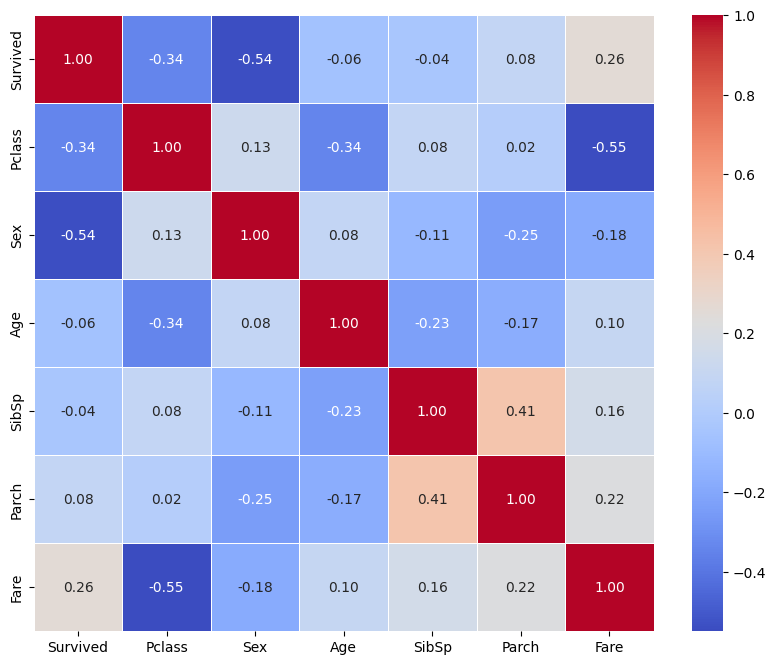

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})
df = df.drop(['PassengerId'],axis = 1)
df = df.drop(columns=['Name'])
df = df.drop(columns=['Ticket'])
df = df.drop(columns=['Cabin'])

# Calculate correlation matrix
corr_matrix = df.corr()


# Plot heatmap of correlation matrix
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.show()

6.PCA

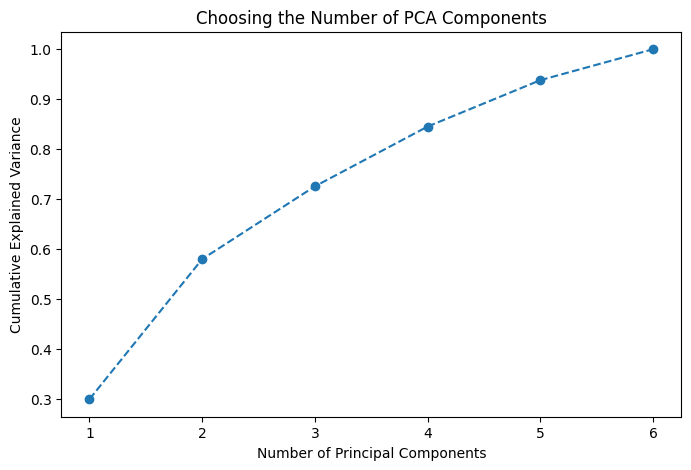

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Selecting numerical features
numerical_features = df.select_dtypes(include=['float64', 'int64']).drop(columns=['Survived'], errors='ignore')  # Drop target if applicable

# Standardizing the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_features)

pca = PCA()
pca.fit(scaled_data)

# Calculate cumulative variance
explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Choosing the Number of PCA Components")
plt.show()

In [19]:
# Find the number of components that explain at least 95% variance
optimal_components = np.argmax(explained_variance >= 0.95) + 1
print(f"Optimal number of components: {optimal_components}")


pca = PCA(n_components=optimal_components)
pca_features = pca.fit_transform(scaled_data)

Optimal number of components: 6
